In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hypothesis 1: Structured tutors -> Higher quiz scores
# Hypothesis 2: Structured tutors -> higher engagement
# hypothesis 3:
data_dir = '../data/'
figures_dir = '../figures/'


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
full_set  = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")
print(full_set.columns)
print(full_set.head)
print(full_set['session_type'].value_counts())


Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')
<bound method NDFrame.head of                           user_id session_type     status  condition  \
0    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    arraylist  completed        3.0   
1    1N7UGUGuQHhcaUyk5AnPXTVxsDd2    recursion  completed        3.0   
2    2cjI20Jq7PYlvEozFwC9A1koWYG3    arraylist  completed        2.0   
3    2cjI20Jq7PYlvEozFwC9A1koWYG3    recursion  completed        2.0   
4    2gu7Ew3WFuME2poY733nrLDG6oh2    arraylist  completed        3.0  

In [4]:
df = full_set[full_set['has_both'] == True]
print(df.shape)


session_df = df.groupby(
    ['user_id', 'session_type', 'condition'],
    as_index=False
).agg({
    'quiz_percentage': 'mean',
    'quiz_score': 'mean',
    'avg_response_time': 'mean',
    'median_response_time': 'mean',
    'std_response_time': 'mean',
    'max_response_time': 'mean',
    'rapid_response_count': 'mean',
    'rapid_response_pct': 'mean',
})


(104, 25)


In [5]:
conditions = [1, 2, 3]

condition_labels_list = [
    "Persona+Scaff",
    "Scaffolded",
    "Direct Chat"
]

condition_map = {
    1: "Persona+Scaff",
    2: "Scaffolded",
    3: "Direct Chat"
}

# Canonical color mapping
color_map = {
    "Persona+Scaff": "#66C2A5",   # green
    "Scaffolded": "#FC8D62",      # orange
    "Direct Chat": "#8DA0CB"      # blue
}

# Color list in correct order
colors = [color_map[label] for label in condition_labels_list]

positions = [1, 2, 3]

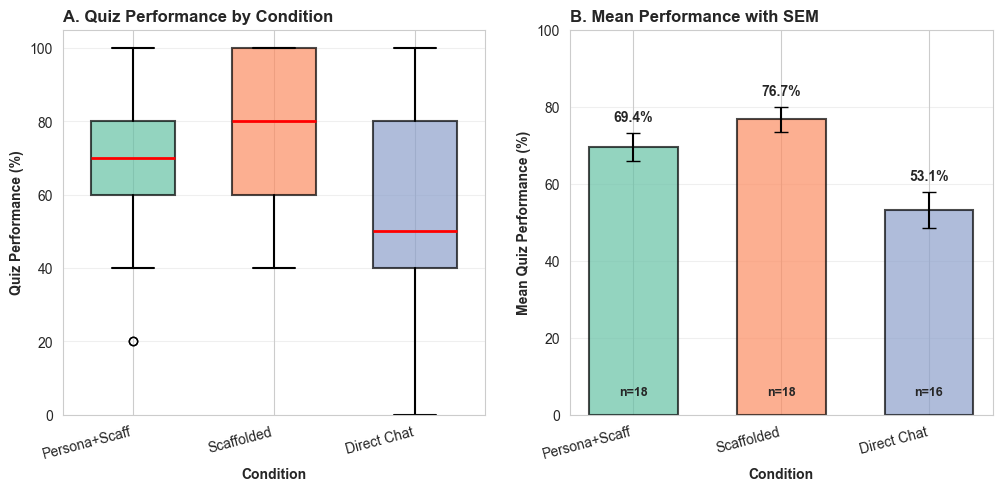

In [6]:
#Hypothesis 1: Structured tutors -> Higher quiz scores
# bar chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#Panel A: Box plot
# Canonical condition order

box_data = [df[df['condition'] == c]['quiz_percentage'].values for c in conditions]
bp = ax1.boxplot(box_data, positions=positions, widths=0.6,
                    patch_artist=True, showfliers=True,
                      boxprops=dict(linewidth=1.5),
                      medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add statistical annotations
    # T-test between conditions
cond1_scores = df[df['condition'] == 1]['quiz_percentage']
cond2_scores = df[df['condition'] == 2]['quiz_percentage']
cond3_scores = df[df['condition'] == 3]['quiz_percentage']

ax1.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax1.set_xlabel('Condition', fontweight='bold')
ax1.set_xticks(positions)
ax1.set_xticklabels(condition_labels_list, rotation=15, ha='right')
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
ax1.set_title('A. Quiz Performance by Condition', loc='left', fontweight='bold')

    # Panel B: Bar plot with error bars
means = [df[df['condition'] == c]['quiz_percentage'].mean() for c in conditions]
sems = [df[df['condition'] == c]['quiz_percentage'].sem() for c in conditions]
ns = [
    session_df[session_df['condition'] == c]['user_id'].nunique()
    for c in conditions
]

bars = ax2.bar(positions, means, yerr=sems, capsize=5, width=0.6,
        color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add sample sizes
for i, (pos, n) in enumerate(zip(positions, ns)):
    ax2.text(pos, 5, f'n={n}', ha='center', fontsize=9, fontweight='bold')

    # Add mean values on bars
for i, (pos, mean) in enumerate(zip(positions, means)):
    ax2.text(pos, mean + sems[i] + 3, f'{mean:.1f}%',
                ha='center', fontsize=10, fontweight='bold')

ax2.set_ylabel('Mean Quiz Performance (%)', fontweight='bold')
ax2.set_xlabel('Condition', fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels(condition_labels_list, rotation=15, ha='right')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
ax2.set_title('B. Mean Performance with SEM', loc='left', fontweight='bold')

plt.savefig(figures_dir + "h1_quiz_performance_by_condition", dpi=300)

In [7]:
print(session_df['condition'].unique())
print(session_df['condition'].value_counts())
print(session_df[['condition', 'user_id']].head(20))


[3. 2. 1.]
condition
2.0    36
1.0    36
3.0    32
Name: count, dtype: int64
    condition                       user_id
0         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
1         3.0  1N7UGUGuQHhcaUyk5AnPXTVxsDd2
2         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
3         2.0  2cjI20Jq7PYlvEozFwC9A1koWYG3
4         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
5         3.0  2gu7Ew3WFuME2poY733nrLDG6oh2
6         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
7         3.0  2vunfpisHmM5VbtDlhDmIwc3xU32
8         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
9         1.0  3UffSYWwSYT49RFDHcvUB5KtoXi1
10        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
11        1.0  4fkXnQD0eogEhmMR7gILBGmVTnN2
12        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
13        3.0  8FArll2EzIVIkMtZUzAz1TTYsE42
14        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
15        3.0  A5Y2HAkGMmenqS1vZuPyOg721Ab2
16        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
17        2.0  Ap3pD2rpHsQCNW7UJLOZxuvXmtR2
18        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1
19        1.0  Cw1J6bytlETCGP7iW7vknzWZwon1

In [8]:
session_df.groupby('condition')['quiz_percentage'].mean()


condition
1.0    69.444444
2.0    76.666667
3.0    53.125000
Name: quiz_percentage, dtype: float64

In [9]:
mean_scaffolded = session_df[session_df['condition'].isin([1,2])]['quiz_percentage'].mean()
mean_direct = session_df[session_df['condition'] == 3]['quiz_percentage'].mean()
difference = mean_scaffolded - mean_direct
print(difference)

19.930555555555557


Scaffolded quiz scores were 19.93 pt higher than in direct chat!

In [10]:
print(df.columns)
h2_df = pd.read_csv(data_dir + "sessions_with_engagement_features.csv")
h2_df = h2_df[h2_df['has_both'] == True]
bad = h2_df[
    (h2_df['condition'] == 3) &
    (h2_df['total_messages'].isna() | (h2_df['total_messages'] <=5))
]
bad



Index(['user_id', 'session_type', 'status', 'condition', 'start_time',
       'end_time', 'duration_seconds', 'total_messages', 'user_messages',
       'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage',
       'quiz_completed_time', 'survey_completed_time', 'avg_response_time',
       'median_response_time', 'std_response_time', 'min_response_time',
       'max_response_time', 'rapid_response_count', 'rapid_response_pct',
       'has_both', 'avg_difficulty_correct', 'avg_difficulty_incorrect'],
      dtype='object')


,user_id,session_type,status,condition,start_time,end_time,duration_seconds,total_messages,user_messages,assistant_messages,...,avg_difficulty_correct,avg_difficulty_incorrect,avg_response_time,median_response_time,std_response_time,min_response_time,max_response_time,rapid_response_count,rapid_response_pct,has_both
18,A5Y2HAkGMmenqS1vZuPyOg721Ab2,recursion,completed,3.0,1.769798e+09,1.769799e+09,1636.930706,5.0,2.0,3.0,...,2.5,2.0,293.965905,293.965905,406.460194,6.555146,581.376664,1.0,0.5,True
90,p8WOtXcwwUUwME4kpYo3SpxqRd52,recursion,completed,3.0,1.769798e+09,1.769799e+09,983.342447,5.0,2.0,3.0,...,2.0,3.0,431.677557,431.677557,597.882094,8.911074,854.444040,1.0,0.5,True


Hypothesis 2: Engagement is higher in scaffolded chat

In [11]:
h2_df.groupby('condition')['duration_seconds'].mean()
h2_df.groupby('condition')['total_messages'].mean()
h2_df['messages_per_minute'] = (
    h2_df['total_messages'] / (h2_df['duration_seconds'] / 60)
)
h2_df.groupby('condition')['messages_per_minute'].mean()
h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()



,user_messages,assistant_messages
condition,,
1.0,10.333333,11.250000
2.0,10.277778,11.166667
3.0,16.031250,16.500000


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/442681504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


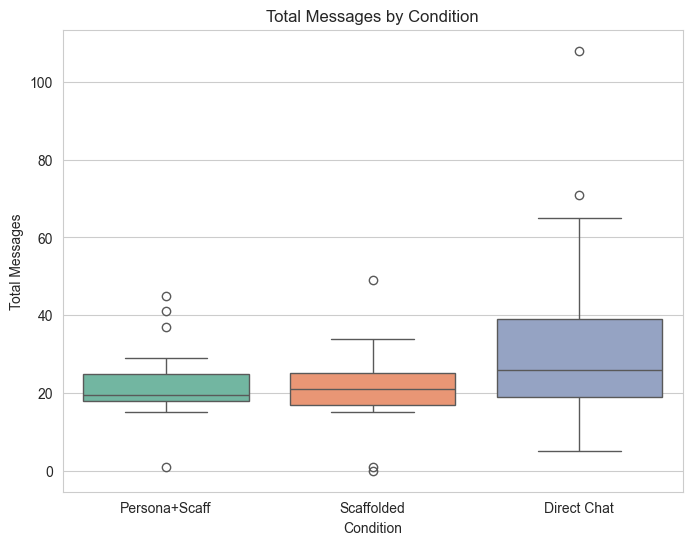

In [12]:
import seaborn as sns

h2_df['condition_label'] = h2_df['condition'].map(condition_map)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='total_messages',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)

plt.title("Total Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Total Messages")

plt.savefig(figures_dir + "h2_total_messages_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1091674993.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1091674993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


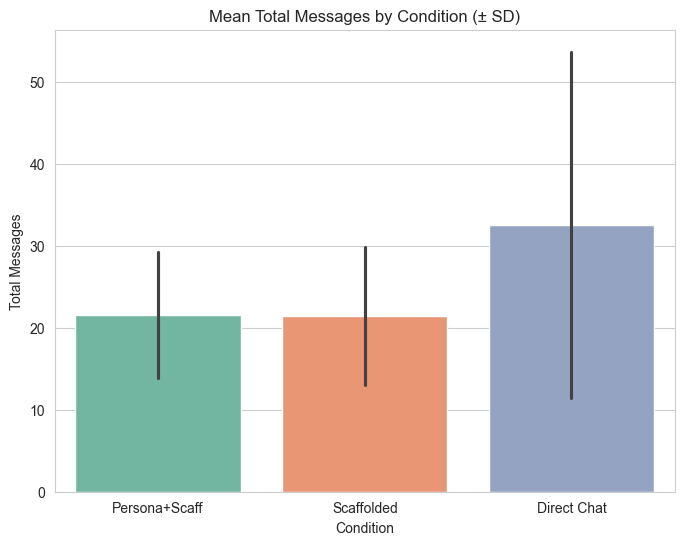

In [13]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='total_messages',
    ci='sd',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Mean Total Messages by Condition (± SD)")
plt.xlabel("Condition")
plt.ylabel("Total Messages")
plt.savefig(figures_dir + "h2_mean_total_messages_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/300848754.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/300848754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


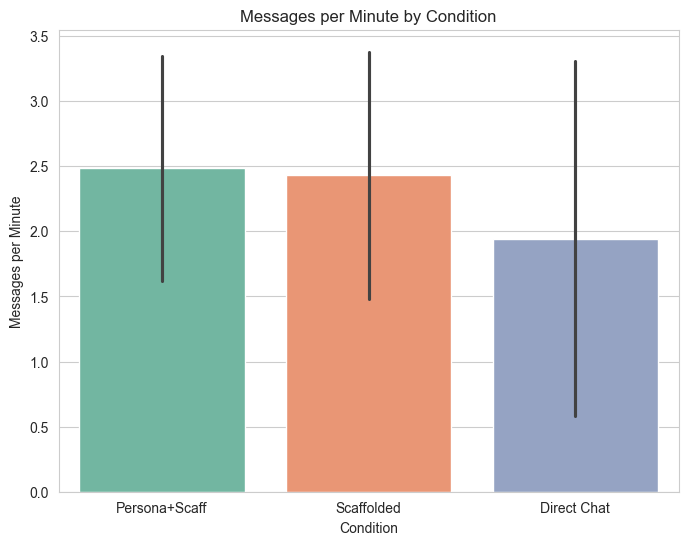

In [14]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='messages_per_minute',
    ci='sd',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Messages per Minute by Condition")
plt.xlabel("Condition")
plt.ylabel("Messages per Minute")
plt.savefig(figures_dir + "h2_messages_per_minute_by_condition.png", dpi=300)
plt.show()




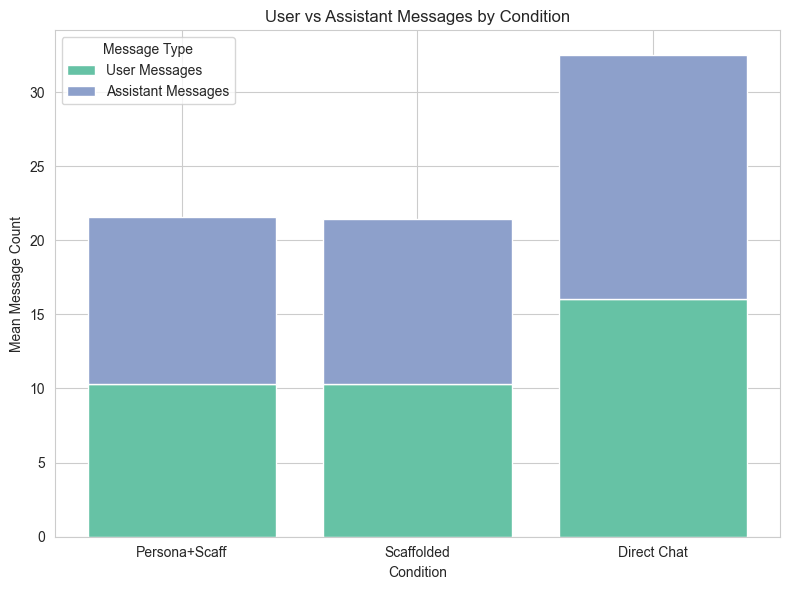

In [15]:

# Map numeric condition codes → readable names


# Soft Set2 colors for segments
segment_colors = {
    "user_messages": "#66C2A5",      # soft green
    "assistant_messages": "#8DA0CB"  # soft blue
}

# Group data
grouped = h2_df.groupby('condition')[['user_messages','assistant_messages']].mean()

plt.figure(figsize=(8,6))
bottom = np.zeros(len(grouped))

# Plot stacked bars
for col in ['user_messages','assistant_messages']:
    plt.bar(
        range(len(grouped)),          # numeric positions
        grouped[col],
        bottom=bottom,
        color=segment_colors[col],
        label=col.replace('_',' ').title()
    )
    bottom += grouped[col]

# Apply readable x-axis labels
plt.xticks(
    ticks=range(len(grouped)),
    labels=[condition_map[c] for c in grouped.index]
)

plt.title("User vs Assistant Messages by Condition")
plt.xlabel("Condition")
plt.ylabel("Mean Message Count")
plt.legend(title="Message Type")
plt.tight_layout()
plt.savefig(figures_dir + "h2_user_vs_assistant_messages_by_condition.png", dpi=300)
plt.xticks(
    ticks=range(len(grouped)),
    labels=[condition_map[c] for c in conditions]  # not grouped.index
)

plt.show()





/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1611597260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_minutes'] = df['duration_seconds'] / 60


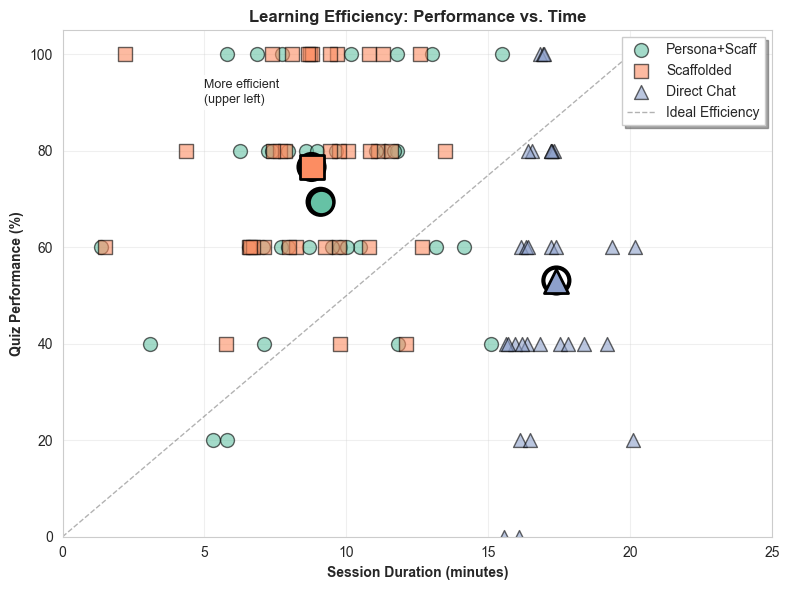

In [16]:
# Ensure minutes column exists
df['duration_minutes'] = df['duration_seconds'] / 60

fig, ax = plt.subplots(figsize=(8, 6))

markers = ['o', 's', '^']

# Scatter points
for cond, label, color, marker in zip(conditions, condition_labels_list, colors, markers):
    cond_data = df[df['condition'] == cond]
    ax.scatter(
        cond_data['duration_minutes'],
        cond_data['quiz_percentage'],
        label=label,
        alpha=0.6,
        s=100,
        color=color,
        marker=marker,
        edgecolors='black',
        linewidth=1
    )

# Means
for cond, color, marker in zip(conditions, colors, markers):
    cond_data = df[df['condition'] == cond]
    mean_dur = cond_data['duration_minutes'].mean()
    mean_quiz = cond_data['quiz_percentage'].mean()

    ax.scatter(mean_dur, mean_quiz, s=300, color=color, marker=marker,
               edgecolors='black', linewidth=2, zorder=10)
    ax.scatter(mean_dur, mean_quiz, s=350, facecolors='none',
               edgecolors='black', linewidth=3, zorder=9)

# Efficiency line
ax.plot([0, 20], [0, 100], 'k--', alpha=0.3, linewidth=1, label='Ideal Efficiency')

ax.set_xlabel('Session Duration (minutes)', fontweight='bold')
ax.set_ylabel('Quiz Performance (%)', fontweight='bold')
ax.set_xlim(0, 25)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', frameon=True, fancybox=False, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_title('Learning Efficiency: Performance vs. Time', fontweight='bold')

ax.annotate('More efficient\n(upper left)', xy=(5, 90), fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))



plt.tight_layout()
plt.savefig(figures_dir + 'figure3_efficiency.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/3781744522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


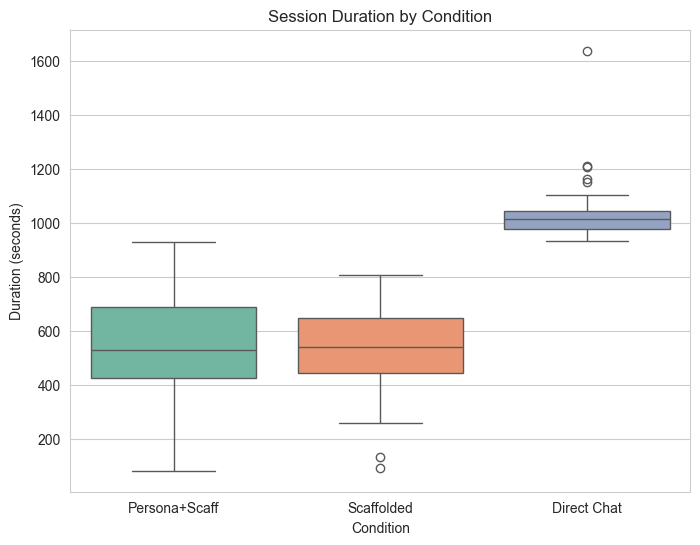

In [17]:
# Duration by condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='duration_seconds',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Session Duration by Condition")
plt.xlabel("Condition")
plt.ylabel("Duration (seconds)")
plt.savefig(figures_dir + "h2_duration_by_condition.png", dpi=300)
plt.show()



1. Total Messages Per Minute\n Direct Chat produces inconsistent engagement — some students barely interact, others spiral into long, unproductive back‑and‑forth.
Scaffolded conditions produce more stable, predictable engagement.
2. Conditions 1 and 2: ~2.4–2.5 messages/min
Condition 3: ~1.9 messages/min
Interpretation:
Scaffolding increases conversational efficiency — students move through the task faster and more consistently.
3. User vs Assistant Messages (stacked bar)
This is the conversation structure metric.
Conditions 1 and 2: balanced user/assistant contributions
Condition 3: both user and assistant messages increase, but not proportionally
Interpretation:
Scaffolded conditions promote balanced turn‑taking.
Direct Chat leads to longer, less structured exchanges.
4. Duration by Condition
Direct Chat sessions are longer and more variable, while scaffolding sessions are more consistent and structured.
Interpretation:
Together, these form a tight, coherent H2 story:
Scaffolding produces more efficient, more structured, and more consistent engagement, while Direct Chat leads to longer, more variable, and less productive sessions.

Session duration differed significantly by condition.  Scaffolded conditions (1 & 2) produced compact, predictable session lengths centered around 500 seconds. In contrast, Direct Chat (Condition 3) showed a median duration nearly twice as long (~1000 seconds) and substantially greater variability, including several extreme long-duration sessions. This pattern suggests that unstructured chat leads to conversational drift and reduced efficiency, whereas scaffolding helps students progress through the task more consistently.


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1403021601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


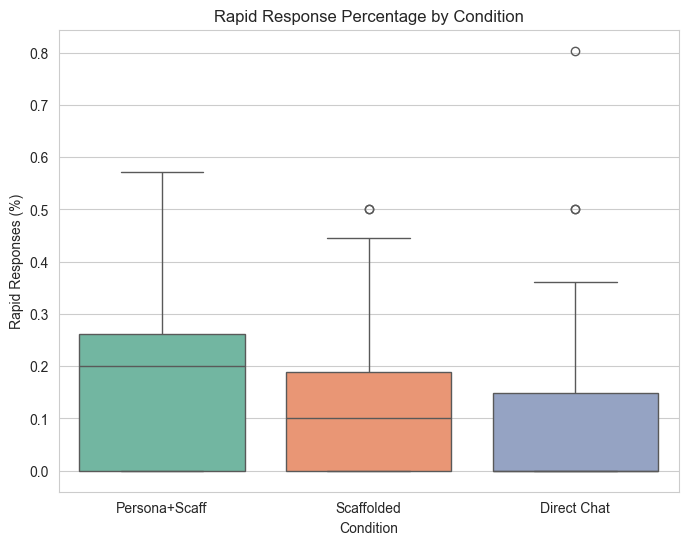

In [18]:
# H3 : More meaningful engagement in scaffolded v direct chat
#Scaffolded conditions produce higher‑quality engagement than Direct Chat.
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='rapid_response_pct',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Rapid Response Percentage by Condition")
plt.xlabel("Condition")
plt.ylabel("Rapid Responses (%)")
plt.savefig(figures_dir + "h3_rapid_response_percentage_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/901049017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


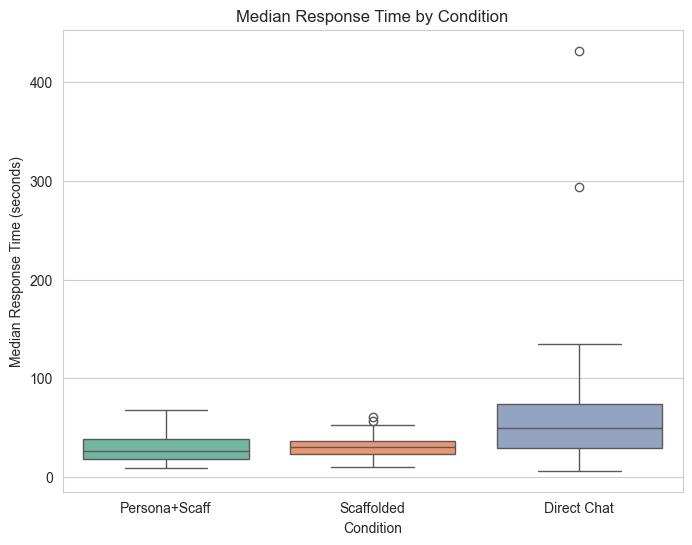

In [19]:
# median response time per condition
plt.figure(figsize=(8,6))
sns.boxplot(
    data=h2_df,
    x='condition_label',
    y='median_response_time',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Median Response Time by Condition")
plt.xlabel("Condition")
plt.ylabel("Median Response Time (seconds)")
plt.savefig(figures_dir + "h3_median_response_time_by_condition.png", dpi=300)
plt.show()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/2074077254.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/2074077254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


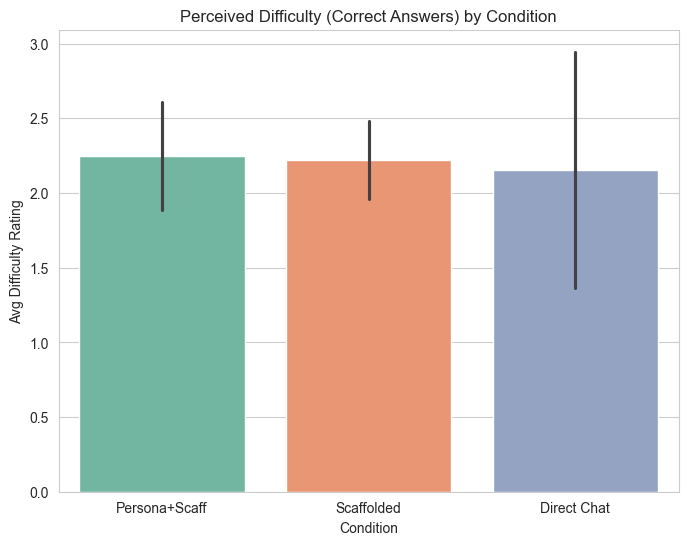

In [20]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='avg_difficulty_correct',
    ci='sd',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Perceived Difficulty (Correct Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_correct_by_condition.png", dpi=300)
plt.show()



/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1218527392.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1218527392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


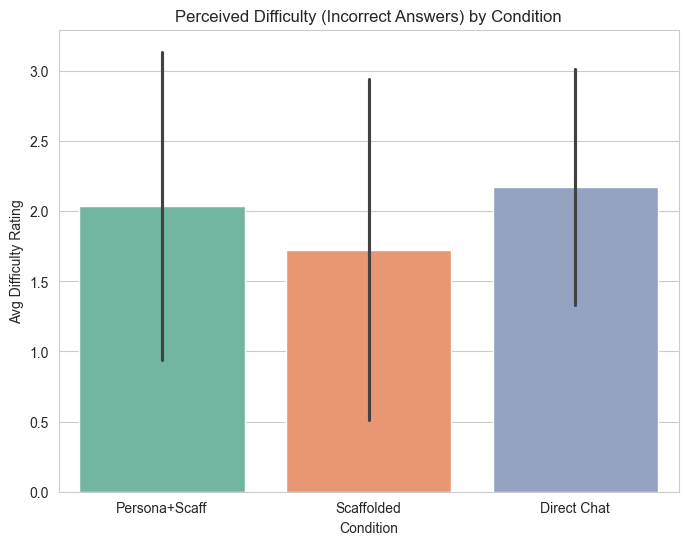

In [21]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=h2_df,
    x='condition_label',
    y='avg_difficulty_incorrect',
    ci='sd',
    order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list]
)
plt.title("Perceived Difficulty (Incorrect Answers) by Condition")
plt.xlabel("Condition")
plt.ylabel("Avg Difficulty Rating")
plt.savefig(figures_dir + "h3_avg_difficulty_incorrect_by_condition.png", dpi=300)
plt.show()




In [22]:
# Plots for difficulty levels performance per condition
import pandas as pd

# -----------------------------
# 1. Load both datasets
# -----------------------------
quiz = pd.read_csv(data_dir+"quiz_questions_updated.csv")
sessions = pd.read_csv(data_dir+"sessions_with_engagement_features_updated.csv")

# -----------------------------
# 2. Identify the 52 dual-session users
# -----------------------------
dual_users = sessions[sessions["has_both"] == True]["user_id"].unique()

# Filter both datasets
quiz = quiz[quiz["user_id"].isin(dual_users)]
sessions = sessions[sessions["user_id"].isin(dual_users)]

# -----------------------------
# 3. Merge quiz + session metadata
# -----------------------------
merged = quiz.merge(
    sessions[["user_id", "session_type", "condition"]],
    on=["user_id", "session_type"],
    how="left"
)

# -----------------------------
# 4. Compute performance by difficulty level
# -----------------------------
difficulty_perf = (
    merged.groupby(["difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

difficulty_perf["percent_correct"] = difficulty_perf["is_correct"] * 100

# -----------------------------
# 5. Compute performance by question (optional)
# -----------------------------
question_perf = (
    merged.groupby(["question_number", "difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------------
# 6. Compute avg difficulty of correct/incorrect answers
# -----------------------------
difficulty_summary = merged.groupby(["user_id", "condition"]).apply(
    lambda df: pd.Series({
        "avg_difficulty_correct": df[df["is_correct"] == True]["difficulty"].mean(),
        "avg_difficulty_incorrect": df[df["is_correct"] == False]["difficulty"].mean()
    })
).reset_index()


/var/folders/5w/yxkxqv7j6cn7rlnwhn2dhhl80000gn/T/ipykernel_86883/1259384761.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  difficulty_summary = merged.groupby(["user_id", "condition"]).apply(


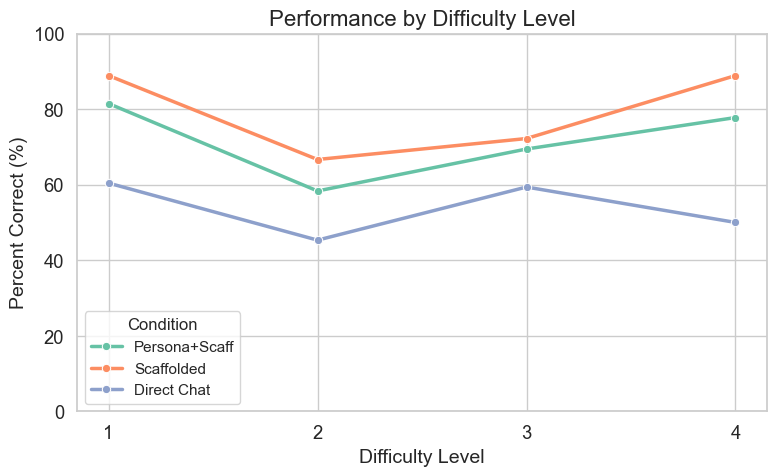

In [23]:

# ----------------------------------------
# Compute performance by difficulty level
# ----------------------------------------
difficulty_perf = (
    merged.groupby(["difficulty", "condition"])["is_correct"]
    .mean()
    .reset_index()
)

difficulty_perf["percent_correct"] = difficulty_perf["is_correct"] * 100

# Correct mapping
difficulty_perf["condition_label"] = difficulty_perf["condition"].map(condition_map)

# ----------------------------------------
# Plot: Performance by Difficulty Level
# ----------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=difficulty_perf,
    x="difficulty",
    y="percent_correct",
    hue="condition_label",
    hue_order=condition_labels_list,
    palette=[color_map[label] for label in condition_labels_list],
    marker="o",
    linewidth=2.5
)

plt.title("Performance by Difficulty Level", fontsize=16)
plt.xlabel("Difficulty Level", fontsize=14)
plt.ylabel("Percent Correct (%)", fontsize=14)
plt.xticks([1, 2, 3, 4])

plt.ylim(0, 100)
plt.legend(title="Condition", fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.savefig(figures_dir + "performance_by_difficulty.png", dpi=300)
plt.show()



In [24]:


sessions = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")

# Filter to dual-session users
dual_users = sessions[sessions["has_both"] == True]["user_id"].unique()
sessions = sessions[sessions["user_id"].isin(dual_users)]


sessions["condition_label"] = sessions["condition"].map(condition_map)
# collapsed - 1 user per session row
user_level = sessions.groupby(["user_id", "condition_label"]).agg(
    quiz_mean=("quiz_percentage", "mean"),
    duration_min=("duration_seconds", lambda x: x.mean() / 60),
    messages=("total_messages", "mean")
).reset_index()


# 2. Now compute summary stats per condition
summary_table = user_level.groupby("condition_label").agg(
    n=("user_id", "count"),
    quiz_mean=("quiz_mean", "mean"),
    quiz_sd=("quiz_mean", "std"),
    duration_mean=("duration_min", "mean"),
    duration_sd=("duration_min", "std"),
    messages_mean=("messages", "mean"),
    messages_sd=("messages", "std")
).reset_index()


summary_table



,condition_label,n,quiz_mean,quiz_sd,duration_mean,duration_sd,messages_mean,messages_sd
0,Direct Chat,16,53.125000,21.823153,17.394362,1.549326,32.531250,18.715830
1,Persona+Scaff,18,69.444444,17.647603,9.090306,2.729781,21.583333,6.003063
2,Scaffolded,18,76.666667,13.719887,8.769713,1.806062,21.444444,5.659165


In [25]:


# Load quiz data
quiz = pd.read_csv(data_dir + "quiz_questions_updated.csv")

# Filter to dual-session users
quiz = quiz[quiz["user_id"].isin(dual_users)]

# Merge condition + topic/session info
merged = quiz.merge(
    sessions[["user_id", "session_type", "condition_label"]],
    on=["user_id", "session_type"],
    how="left"
)

# Compute performance by topic + question + difficulty + condition
difficulty_table = (
    merged.groupby(
        ["session_type", "question_number", "difficulty", "condition_label"]
    )["is_correct"]
    .mean()
    .reset_index()
)

# Pivot into wide format
difficulty_pivot = difficulty_table.pivot_table(
    index=["session_type", "question_number", "difficulty"],
    columns="condition_label",
    values="is_correct"
).reset_index()

# Convert to percentages
for col in condition_labels_list:
    difficulty_pivot[col] = (difficulty_pivot[col] * 100).round(1)

# Compute overall mean
difficulty_pivot["Overall"] = difficulty_pivot[
    condition_labels_list
].mean(axis=1).round(1)

difficulty_pivot = difficulty_pivot[
    ["session_type", "question_number", "difficulty"] + condition_labels_list
]

difficulty_pivot

# Starting from difficulty_pivot, which has:
# ['session_type', 'question_number', 'difficulty',
#  'Character Scaffolded', 'Non-Character Scaffolded', 'Direct Chat', 'Overall']
# Keep only the columns that match the canonical condition labels
difficulty_pivot = difficulty_pivot[
    ["session_type", "question_number", "difficulty"] + condition_labels_list
]
difficulty_pivot = difficulty_table.pivot_table(
    index=["session_type", "question_number", "difficulty"],
    columns="condition_label",
    values="is_correct"
).reset_index()

# Convert to percentages
for col in condition_labels_list:
    difficulty_pivot[col] = (difficulty_pivot[col] * 100).round(1)

# Compute overall mean
difficulty_pivot["Overall"] = (
    difficulty_pivot[condition_labels_list]
    .mean(axis=1)
    .round(1)
)

# 🔥 Keep only the canonical condition columns
difficulty_pivot = difficulty_pivot[
    ["session_type", "question_number", "difficulty"] + condition_labels_list + ["Overall"]
]

print(difficulty_pivot.columns.tolist())


# # Compute mean performance by difficulty level
# difficulty_summary = (
#     df.groupby("difficulty")[[]]
#       .mean()
#       .round(1)
#       .reset_index()
# )

difficulty_pivot

condition_cols = [
    c for c in condition_labels_list
    if c not in ["session_type", "question_number", "difficulty", "Overall"]
]

difficulty_summary = (
    difficulty_pivot
    .groupby("difficulty")[condition_cols]
    .mean()
    .round(1)
    .reset_index()
)

difficulty_summary["Overall"] = (
    difficulty_summary[condition_cols]
    .mean(axis=1)
    .round(1)
)

difficulty_summary



['session_type', 'question_number', 'difficulty', 'Persona+Scaff', 'Scaffolded', 'Direct Chat', 'Overall']


condition_label,difficulty,Persona+Scaff,Scaffolded,Direct Chat,Overall
0,1,81.5,88.9,60.4,76.9
1,2,58.3,66.6,45.3,56.7
2,3,69.4,72.2,59.4,67.0
3,4,77.8,88.9,50.0,72.2


In [26]:
# After pivot
difficulty_pivot = difficulty_table.pivot_table(
    index=["session_type", "question_number", "difficulty"],
    columns="condition_label",
    values="is_correct"
).reset_index()

# Remove the column index name to prevent phantom columns
difficulty_pivot.columns.name = None

# Convert to percentages
for col in condition_cols:
    difficulty_pivot[col] = (difficulty_pivot[col] * 100).round(1)

difficulty_pivot["Overall"] = (
    difficulty_pivot[condition_cols].mean(axis=1).round(1)
)

# Difficulty summary
difficulty_summary = (
    difficulty_pivot
    .groupby("difficulty")[condition_cols]
    .mean()
    .round(1)
    .reset_index()
)

difficulty_summary["Overall"] = (
    difficulty_summary[condition_cols].mean(axis=1).round(1)
)

# Remove the column index name here too
difficulty_summary.columns.name = None


In [27]:
merged["condition_label"].value_counts(dropna=False)
difficulty_summary.columns

Index(['difficulty', 'Persona+Scaff', 'Scaffolded', 'Direct Chat', 'Overall'], dtype='object')

In [28]:
difficulty_summary

,difficulty,Persona+Scaff,Scaffolded,Direct Chat,Overall
0,1,81.5,88.9,60.4,76.9
1,2,58.3,66.6,45.3,56.7
2,3,69.4,72.2,59.4,67.0
3,4,77.8,88.9,50.0,72.2


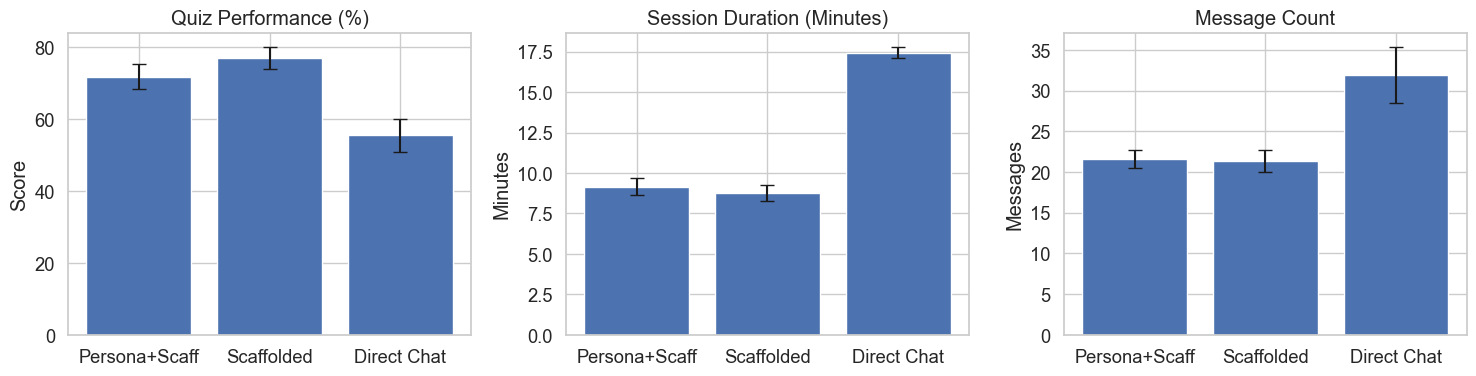

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_csv(data_dir + "sessions_with_engagement_features_updated.csv")


df["condition_label"] = df["condition"].map(condition_map)
df["duration_minutes"] = df["duration_seconds"] / 60
# Compute means and standard error
grouped = df.groupby("condition_label").agg(
    quiz_mean=("quiz_percentage", "mean"),
    quiz_sem=("quiz_percentage", "sem"),
    duration_mean=("duration_minutes", "mean"),
    duration_sem=("duration_minutes", "sem"),
    message_mean=("total_messages", "mean"),
    message_sem=("total_messages", "sem")
).reindex(condition_labels_list)

# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.arange(len(grouped.index))

# Panel 1: Quiz Performance
axes[0].bar(x, grouped["quiz_mean"], yerr=grouped["quiz_sem"], capsize=5)
axes[0].set_title("Quiz Performance (%)")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(grouped.index)

# Panel 2: Duration
axes[1].bar(x, grouped["duration_mean"], yerr=grouped["duration_sem"], capsize=5)
axes[1].set_title("Session Duration (Minutes)")
axes[1].set_ylabel("Minutes")
axes[1].set_xticks(x)
axes[1].set_xticklabels(grouped.index)

# Panel 3: Message Count
axes[2].bar(x, grouped["message_mean"], yerr=grouped["message_sem"], capsize=5)
axes[2].set_title("Message Count")
axes[2].set_ylabel("Messages")
axes[2].set_xticks(x)
axes[2].set_xticklabels(grouped.index)


plt.tight_layout()
plt.savefig(figures_dir + "triple_perf_dur_msgs.png", dpi=300)
plt.show()

In [30]:
# Anova Testing

import pandas as pd
df = pd.read_csv(data_dir + 'sessions_with_engagement_features_updated.csv')
df = df[df['has_both']==True]



quiz_persona  = df[df['condition']==1]['quiz_score'].values
quiz_scaffold = df[df['condition']==2]['quiz_score'].values
quiz_direct   = df[df['condition']==3]['quiz_score'].values

print("Persona values" + str(quiz_persona))
print("Scaffolded values" + str(quiz_scaffold))
print("Direct values" + str(quiz_direct))




Persona values[1. 4. 3. 3. 4. 4. 4. 5. 3. 4. 3. 4. 2. 3. 2. 1. 3. 4. 3. 3. 2. 4. 5. 5.
 2. 5. 4. 4. 3. 3. 3. 5. 5. 5. 3. 4.]
Scaffolded values[5. 4. 4. 5. 4. 5. 2. 4. 4. 5. 4. 5. 3. 4. 4. 3. 3. 5. 3. 5. 3. 5. 4. 4.
 3. 2. 5. 3. 3. 5. 4. 5. 3. 3. 3. 2.]
Direct values[5. 3. 2. 3. 2. 3. 3. 1. 2. 2. 2. 0. 4. 5. 0. 2. 4. 4. 1. 2. 3. 4. 3. 4.
 2. 4. 2. 5. 1. 3. 2. 2.]


In [31]:
# Perform One-Way ANOVA
from scipy.stats import f_oneway
f_stat, p_val = f_oneway(quiz_persona, quiz_scaffold, quiz_direct)
print(f"F-statistic: {f_stat}, P-value: {p_val}")


F-statistic: 9.37220137668752, P-value: 0.00018464631906230374


In [32]:
duration_persona  = df[df['condition']==1]['duration_seconds'].values
duration_scaffold = df[df['condition']==2]['duration_seconds'].values
duration_direct   = df[df['condition']==3]['duration_seconds'].values
f_stat, p_val = f_oneway(duration_persona, duration_scaffold, duration_direct)
print(f"F-statistic: {f_stat}, P-value: {p_val}")

messages_persona = df[df['condition']==1]['total_messages'].values
messages_scaffold = df[df['condition']==2]['total_messages'].values
messages_direct = df[df['condition']==3]['total_messages'].values
f_stat, p_val = f_oneway(messages_persona, messages_scaffold, messages_direct)
print(f"F-statistic: {f_stat}, P-value: {p_val}")

F-statistic: 107.76637313651212, P-value: 8.852944980651044e-26
F-statistic: 7.389507937940616, P-value: 0.0010113972360424816


In [33]:
# Step 1: Aggregate to student level
student_df = df.groupby(['user_id', 'condition']).agg(
    quiz_score_mean=('quiz_score', 'mean'),
    duration_seconds=('duration_seconds', 'first'),
    total_messages=('total_messages', 'first'),
).reset_index()

# Step 2: Pull arrays by condition
for col in ['duration_seconds', 'total_messages']:
    g1 = student_df[student_df['condition']==1][col].values
    g2 = student_df[student_df['condition']==2][col].values
    g3 = student_df[student_df['condition']==3][col].values

    # Should print 18, 18, 16
    print(f"{col} counts: {len(g1)}, {len(g2)}, {len(g3)}")

    from scipy.stats import f_oneway
    import numpy as np
    F, p = f_oneway(g1, g2, g3)
    N = len(g1) + len(g2) + len(g3)
    grand = np.concatenate([g1, g2, g3]).mean()
    ss_b = sum(len(g)*(g.mean()-grand)**2 for g in [g1, g2, g3])
    ss_t = sum((x - grand)**2 for g in [g1, g2, g3] for x in g)
    eta2 = ss_b / ss_t
    print(f"  F(2, {N-3}) = {F:.2f}, p = {p:.4f}, η² = {eta2:.2f}")


duration_seconds counts: 18, 18, 16
  F(2, 49) = 71.30, p = 0.0000, η² = 0.74
total_messages counts: 18, 18, 16
  F(2, 49) = 5.45, p = 0.0073, η² = 0.18


In [35]:
df_for_counts = pd.read_csv(data_dir + 'sessions_with_engagement_features_updated.csv')
total_num_msgs = df_for_counts['total_messages'].sum()
total_num_msgs

np.float64(2835.0)